# **DATA ANALYSIS USING PYTHON - BLINKIT ANALYSIS**

#### __import libraries__

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### __import raw data__

In [2]:
df=pd.read_csv("blinkit_data.csv")

#### __sample data__

In [3]:
df.head(20)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0
5,low fat,FDS52,Frozen Foods,2020,OUT017,Tier 2,Small,Supermarket Type1,0.005505,8.89,102.4016,5.0
6,Low Fat,NCU05,Health and Hygiene,2011,OUT010,Tier 3,Small,Grocery Store,0.098312,11.80,81.4618,5.0
7,Low Fat,NCD30,Household,2015,OUT045,Tier 2,Small,Supermarket Type1,0.026904,19.70,96.0726,5.0
8,Low Fat,FDW20,Fruits and Vegetables,2014,OUT013,Tier 3,High,Supermarket Type1,0.024129,20.75,124.1730,5.0
9,Low Fat,FDX25,Canned,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.101562,NaN,181.9292,5.0


In [4]:
df.tail(10)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
8513,Regular,DRY23,Soft Drinks,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.108568,NaN,42.9112,4.0
8514,low fat,FDA11,Baking Goods,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.043029,NaN,94.7436,4.0
8515,low fat,FDK38,Canned,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.053032,NaN,149.1734,4.0
8516,low fat,FDO38,Canned,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.072486,NaN,78.9986,4.0
8517,low fat,FDG32,Fruits and Vegetables,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.175143,NaN,222.3772,4.0
8518,low fat,NCT53,Health and Hygiene,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,164.5526,4.0
8519,low fat,FDN09,Snack Foods,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,NaN,241.6828,4.0
8520,low fat,DRE13,Soft Drinks,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,NaN,86.6198,4.0
8521,reg,FDT50,Dairy,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,NaN,97.8752,4.0
8522,reg,FDM58,Snack Foods,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,112.2544,4.0


#### __size of the data__

In [5]:
print("size of the data:-",df.shape)

size of the data:- (8523, 12)


#### __columns name of the data__

In [6]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

#### __data types__

In [7]:
df.dtypes

Item Fat Content              object
Item Identifier               object
Item Type                     object
Outlet Establishment Year      int64
Outlet Identifier             object
Outlet Location Type          object
Outlet Size                   object
Outlet Type                   object
Item Visibility              float64
Item Weight                  float64
Sales                        float64
Rating                       float64
dtype: object

#### __Data Cleaning__

In [8]:
df["Item Fat Content"]=df["Item Fat Content"].replace({"LF":"Low Fat",
                                                       "low fat":"Low Fat",
                                                       "reg":"Regular",
                                                      " Regular":"Regular"})

In [9]:
df["Item Fat Content"].unique()

array(['Regular', 'Low Fat'], dtype=object)

In [10]:
print(df["Item Fat Content"].unique())

['Regular' 'Low Fat']


# __kpi requirements__

In [11]:
#total sales
total_sales = df["Sales"].sum()
#average sales
avg_sales=df["Sales"].mean()
#no of items sold
no_of_items_sold= df["Sales"].count()
#average rating
average_rating=df["Rating"].mean()
## display
print(f"Total_sales:$ {total_sales:,.0f}")
print(f"Total_sales:$ {avg_sales:,.0f}")
print(f"No of items sold:{no_of_items_sold:,.0f}")
print(f"average_rating:{average_rating:,.1f}")

Total_sales:$ 1,201,681
Total_sales:$ 141
No of items sold:8,523
average_rating:4.0


# __CHARTS REQUIREMENTS__

### __Total sales by fat content__

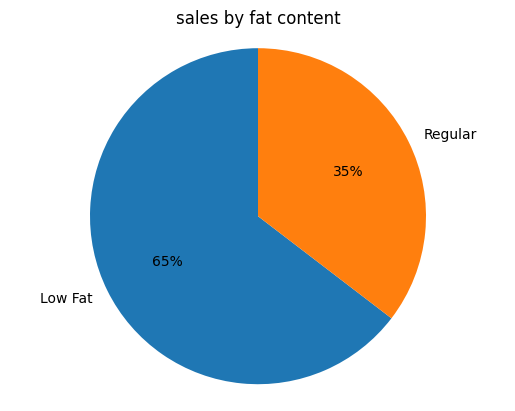

In [12]:
#total sales by fat content 
sales_by_fat=df.groupby("Item Fat Content")["Sales"].sum()
plt.pie(sales_by_fat, labels=sales_by_fat.index,autopct="%.0f%%",
        startangle=90)
plt.title("sales by fat content")
plt.axis("equal")
plt.show()

### __Total sales by item type__

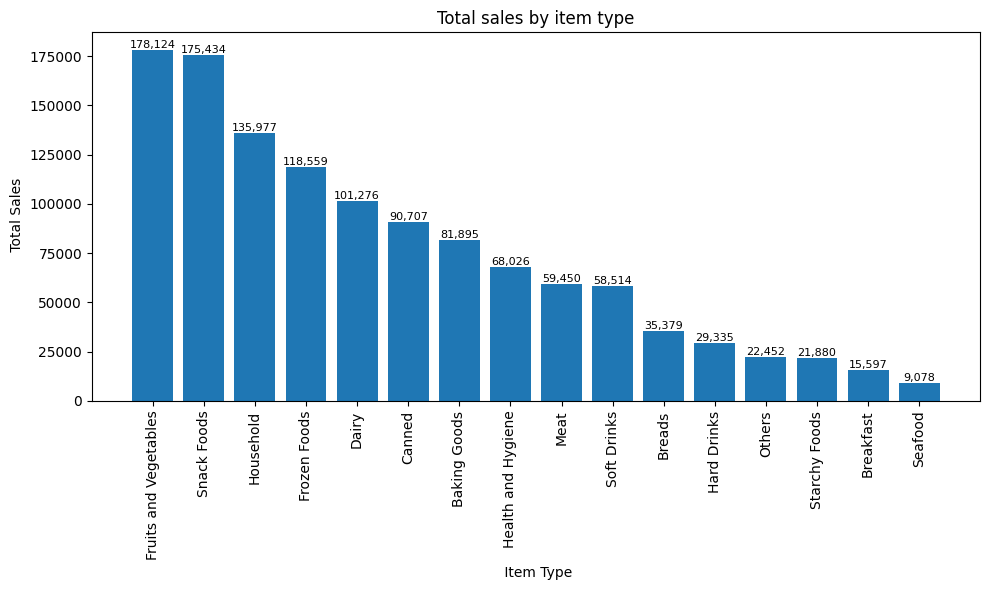

In [13]:
#sales by type
sales_by_type=df.groupby("Item Type")["Sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
bars=plt.bar(sales_by_type.index,sales_by_type.values)
plt.xticks(rotation=90)
plt.xlabel(" Item Type")
plt.ylabel(" Total Sales")
plt.title("Total sales by item type")
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,bar.get_height(),
             f'{bar.get_height():,.0f}',ha="center",va="bottom",fontsize=8)
plt.tight_layout()
plt.show()


### __Fat Content by outlet for total sales__

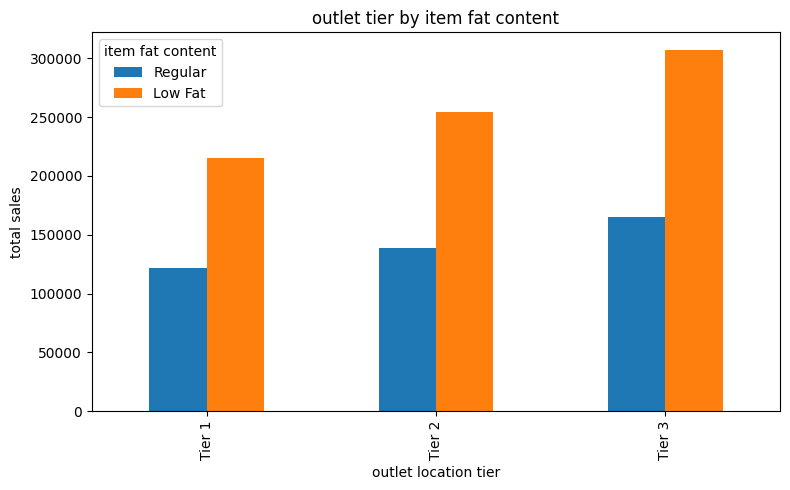

In [14]:
## fat content by outlet for total sales
grouped=df.groupby(["Outlet Location Type","Item Fat Content"])["Sales"].sum().unstack()
grouped=grouped[["Regular","Low Fat"]]
ax=grouped.plot(kind="bar",figsize=(8,5),title="outlet tier by item fat content")
plt.xlabel("outlet location tier")
plt.ylabel("total sales")
plt.legend(title="item fat content")
plt.tight_layout()
plt.show()

### __total sales by outlet establishment__

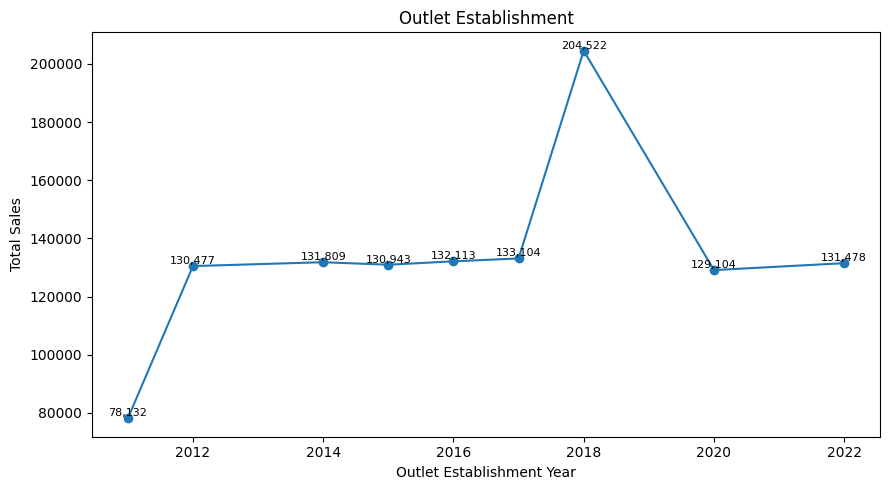

In [15]:
## total sales by outlet establishment 
# Sales by year
sales_by_year = df.groupby('Outlet Establishment Year')['Sales'].sum().sort_index()

plt.figure(figsize=(9, 5))

# Line plot
plt.plot(sales_by_year.index, sales_by_year.values, marker='o', linestyle='-')

# Labels and title
plt.xlabel('Outlet Establishment Year')
plt.ylabel('Total Sales')
plt.title('Outlet Establishment')

# Add values on each point
for x, y in zip(sales_by_year.index, sales_by_year.values):
    plt.text(x, y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8)

# Adjust layout and show
plt.tight_layout()
plt.show()

### __sales by outlet size__

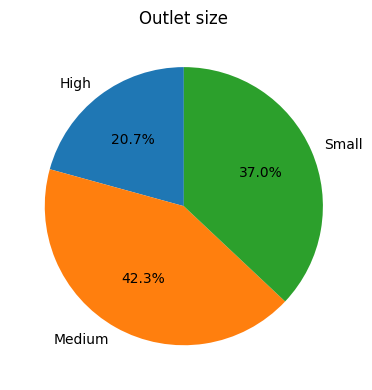

In [16]:
## sales by outlet size 
sales_by_size=df.groupby("Outlet Size")["Sales"].sum()
plt.figure(figsize=(4,4))
plt.pie(sales_by_size,labels=sales_by_size.index,autopct='%1.1f%%',startangle=90)
plt.title("Outlet size")
plt.tight_layout()
plt.show()

### __sales by outlet location__

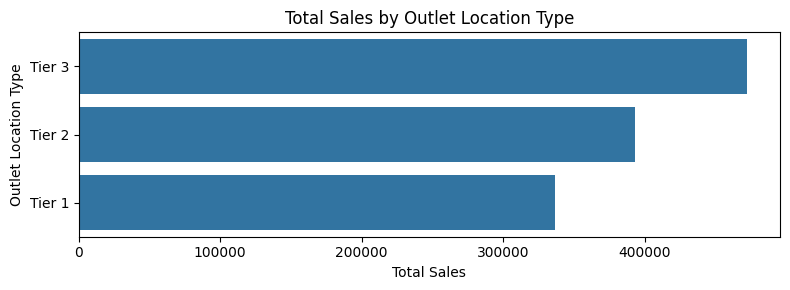

In [17]:
# Sales by outlet location
sales_by_location = df.groupby('Outlet Location Type')['Sales'].sum().reset_index()

# Sort values (highest to lowest)
sales_by_location = sales_by_location.sort_values('Sales', ascending=False)

# Plot
plt.figure(figsize=(8, 3))  # Smaller height, enough width
ax = sns.barplot(x='Sales', y='Outlet Location Type', data=sales_by_location)

# Titles and labels
plt.title('Total Sales by Outlet Location Type')
plt.xlabel('Total Sales')
plt.ylabel('Outlet Location Type')

# Layout adjustment
plt.tight_layout()  # Ensures layout fits without scroll

# Show plot
plt.show()